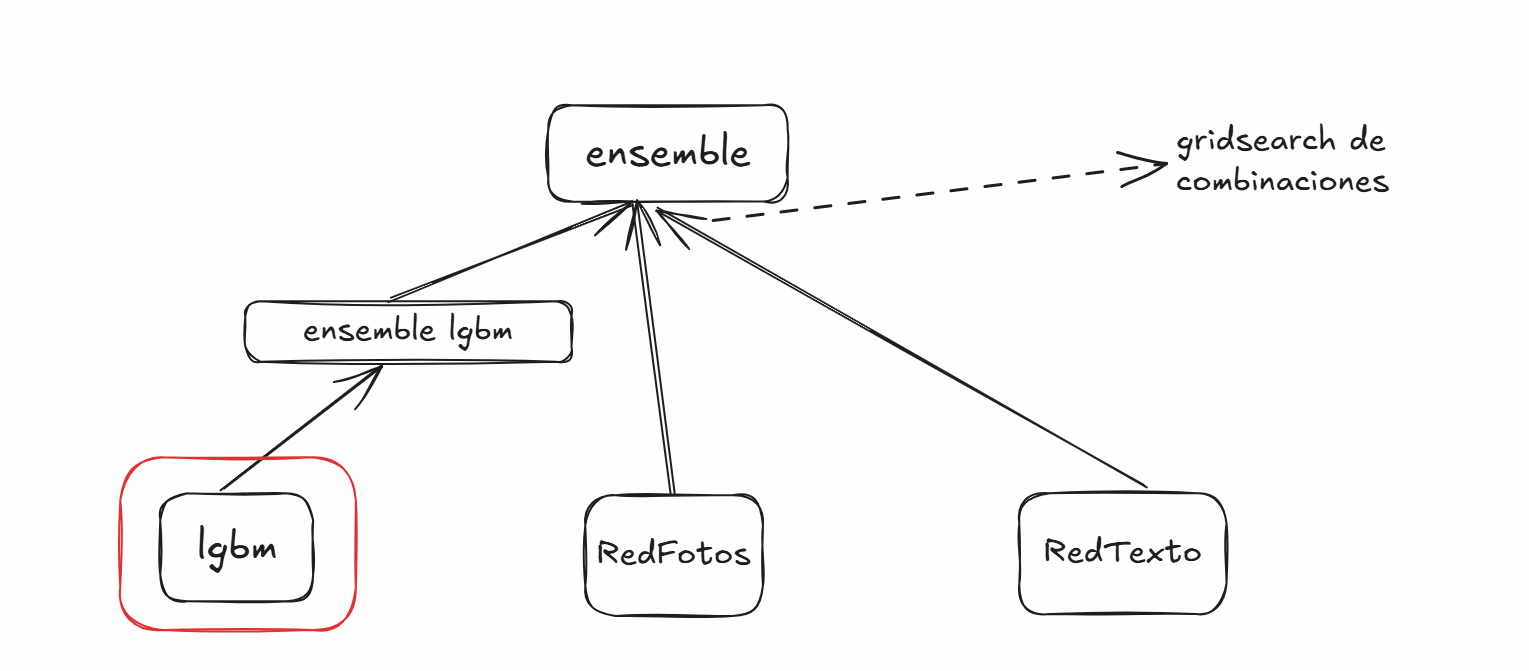

0.  Cargar dataset_FE
1.  Cargar el mejor modelos de lgbm
2.  Hacer en este nb el ensemble de lgbm
3.  Cargar Red Fotos
4.  Cargar Red Texto

In [40]:
import numpy as np 
import pandas as pd 

from sklearn.metrics import cohen_kappa_score, accuracy_score,balanced_accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation

from plotly import express as px

from utils import plot_confusion_matrix, get_artifact_filename

import os

from json import loads

from joblib import load, dump

#Gradient Boosting
import lightgbm as lgb

import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

# Directorios

In [33]:
# Paths
BASE_DIR = '../'
PATH_TO_MODELS = os.path.join(BASE_DIR, "work/models")
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train_FE.csv")
PATH_TO_IMAGES_DIR = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train_images")
PATH_TO_TEMP_FILES = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")
SEED = 42
TEST_SIZE = 0.2 #Facción para train/test= split


# Carga de dataset y division train/test

In [30]:
dataset = pd.read_csv(PATH_TO_TRAIN)

In [34]:
#Separo un 20% para test estratificado opr target
train, test = train_test_split(dataset,
                               test_size = TEST_SIZE,
                               random_state = SEED,
                               stratify = dataset.AdoptionSpeed)

# LGBM

In [3]:
study_lgb = optuna.create_study(direction='maximize',
                            storage="sqlite:///../work/db.sqlite3",  # Specify the storage URL here.
                            study_name="04 - LGB Multiclass CV - FE12",
                            load_if_exists = True)

[I 2025-08-22 16:22:23,371] Using an existing study with name '04 - LGB Multiclass CV - FE12' instead of creating a new one.


In [38]:
final_params = {
    **study_lgb.best_params,  # hiperparámetros de Optuna
    'objective': 'multiclass',
    'num_class': len(y_train.unique()),
    'verbosity': -1,
    'num_threads': 10
}

In [35]:
#Defino features a usar en un primer modelo de prueba
features = ['Type',
 'Age',
 'Breed1',
 'Breed2',
 'Gender',
 'Color1',
 'Color2',
 'Color3',
 'MaturitySize',
 'FurLength',
 'Vaccinated',
 'Dewormed',
 'Sterilized',
 'Health',
 'Quantity',
 'Fee',
 'State',
 'VideoAmt',
 'PhotoAmt',
 'HasName',
 'DescLen',
 'score_salud',
 'Puro',
 'AgeRange',
 'Color_comb',
 'Content',
 'logFee',
 'polarity',
 'Subjectivity',
 'state_gdp',
 'state_population',
 'gdp_vs_population'
 ]

label = 'AdoptionSpeed'

In [36]:
#Genero dataframes de train y test con sus respectivos targets
X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]

In [45]:
lgb_dataset = lgb.Dataset(data=X_train,
                            label=y_train,
                            free_raw_data=False)

In [ ]:
import random

random.seed(SEED) #para hacerlo replicable
n = 200
seed_list = random.sample(range(1, 10000), n)

scores_ensemble = np.zeros((len(y_test),len(y_train.unique())))

n = 0
for seed in seed_list:
    n += 1
    if n%10 == 0 :
        print(f"Vamos por la iteracion {n}")
        
    final_params['seed'] = seed
    
    #Entreno el modelo
    lgb_model = lgb.train(final_params,
                            lgb_dataset,
                            num_boost_round = 100
                            )
    scores_ensemble = scores_ensemble + lgb_model.predict(X_test)

Vamos por la iteracion 10
Vamos por la iteracion 20
